# 관리종목 · 감사의견 종합 EDA
## 목적: 2분기 후 상장폐지 여부 예측을 위한 탐색적 데이터 분석

### 분석 구성
1. 데이터 로드 및 기본 탐색
2. 개별 변수 분포 분석
3. 핵심 관계 분석 (관리종목 ↔ 감사의견 ↔ 상장폐지)
4. 시계열 트렌드 분석
5. 두 모델 예측 결합 및 리스크 스코어링
6. 2분기 후 상장폐지 예측 분석
7. 위험 종목 식별 및 정리

In [1]:
# ── 0. 라이브러리 임포트 ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib import rc
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# 색상 팔레트 정의
COLOR_SAFE   = '#4C72B0'   # 파랑 - 정상
COLOR_WARN   = '#FF8C00'   # 주황 - 경고
COLOR_DANGER = '#D62728'   # 빨강 - 위험
COLOR_DELIST = '#9467BD'   # 보라 - 상장폐지

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 데이터 로드 및 기본 탐색

In [2]:
# ── 1-1. 데이터 로드 ──────────────────────────────────────────────────────

# (A) 전체 학습 데이터 (관리종목 + 감사의견 + 상장폐지 모두 포함)
cd = pd.read_csv('clean_data.csv', encoding='utf-8-sig')

# (B) 관리종목 모델 예측 결과 (2025Q1~Q3)
sp = pd.read_csv('stock_prediction_results.csv', encoding='utf-8-sig')

# (C) 감사의견 모델 예측 결과 (2020Q1~2025Q3)
ap = pd.read_csv('prediction_audit_opinion.csv', encoding='utf-8-sig')

# (D) Y 레이블 데이터 (원본)
yl = pd.read_csv('Y_label_dataset.csv', encoding='utf-8-sig')

print(f'clean_data        : {cd.shape[0]:,}행 × {cd.shape[1]}열')
print(f'관리종목 예측 결과 : {sp.shape[0]:,}행 × {sp.shape[1]}열  ({sorted(sp["quarter"].unique())})')
print(f'감사의견 예측 결과 : {ap.shape[0]:,}행 × {ap.shape[1]}열  ({sorted(ap["quarter"].unique())[0]} ~ {sorted(ap["quarter"].unique())[-1]})')
print(f'Y_label_dataset   : {yl.shape[0]:,}행 × {yl.shape[1]}열')

clean_data        : 39,767행 × 30열
관리종목 예측 결과 : 6,749행 × 6열  (['2025Q1', '2025Q2', '2025Q3'])
감사의견 예측 결과 : 52,725행 × 8열  (2020Q1 ~ 2025Q3)
Y_label_dataset   : 54,130행 × 7열


In [3]:
# ── 1-2. clean_data 기본 정보 ─────────────────────────────────────────────
print('=== clean_data 컬럼 목록 ===')
print(cd.columns.tolist())
print()
print('=== 기술통계 (수치형) ===')
cd.describe().T.round(4)

=== clean_data 컬럼 목록 ===
['stock_code', 'Name', 'quarter', 'Open', 'High', 'Low', 'Close', 'Volume_sum', 'ret_1q', 'logret_1q', 'cumret_4q', 'down_gap_q', 'vol_4q', 'vol_8q', 'max_drawdown_4q', 'ma4', 'ma8', 'ma4_ratio', 'ma_cross_4_8', 'mom_4q', 'vol_z_4q', 'vol_drop_ratio_4q', 'intraquarter_range', 'crash_count_4q', 'down_streak_1q', 'down_streak_4q_max', 'vol_mean_decline_q', '관리종목 여부', '감사의견', '상장폐지 여부']

=== 기술통계 (수치형) ===


,count,mean,std,min,25%,50%,75%,max
stock_code,39767.0,1.096242e+05,1.271158e+05,20.0000,2.018000e+04,6.667000e+04,1.613900e+05,9.502200e+05
Open,39767.0,2.187101e+04,6.333059e+04,0.0000,3.020000e+03,6.700000e+03,1.680000e+04,1.885000e+06
High,39767.0,2.648735e+04,7.648998e+04,0.0000,3.755000e+03,8.250000e+03,2.056250e+04,2.407000e+06
Low,39767.0,1.848320e+04,5.454538e+04,0.0000,2.485000e+03,5.530000e+03,1.395000e+04,1.500000e+06
Close,39767.0,2.212820e+04,6.600023e+04,5.0000,3.000000e+03,6.600000e+03,1.667500e+04,1.900000e+06
Volume_sum,39767.0,4.521152e+07,2.774752e+08,0.0000,3.527736e+06,1.090773e+07,3.226323e+07,2.699062e+10
ret_1q,39767.0,1.140000e-02,3.169000e-01,-0.9946,-1.344000e-01,-2.820000e-02,8.930000e-02,1.613950e+01
logret_1q,39767.0,-2.290000e-02,2.656000e-01,-5.2156,-1.443000e-01,-2.860000e-02,8.560000e-02,2.841400e+00
cumret_4q,39767.0,8.040000e-02,7.801000e-01,-0.9946,-2.830000e-01,-8.380000e-02,2.082000e-01,4.123260e+01
down_gap_q,39767.0,3.229000e-01,4.676000e-01,0.0000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


In [4]:
# ── 1-3. 결측치 확인 ──────────────────────────────────────────────────────
print('=== clean_data 결측치 ===')  
missing = cd.isnull().sum()
print(missing[missing > 0])
print(f'\n총 행 수: {len(cd):,}  |  결측치 없는 행: {cd.dropna().shape[0]:,}')
print()
print('=== 분기 범위 ===')
print(f'clean_data: {sorted(cd["quarter"].unique())[0]} ~ {sorted(cd["quarter"].unique())[-1]}')
print(f'종목 수: {cd["stock_code"].nunique():,}개')

=== clean_data 결측치 ===
Series([], dtype: int64)

총 행 수: 39,767  |  결측치 없는 행: 39,767

=== 분기 범위 ===
clean_data: 2021Q1 ~ 2025Q3
종목 수: 2,512개


---
## 2. 개별 변수 분포 분석

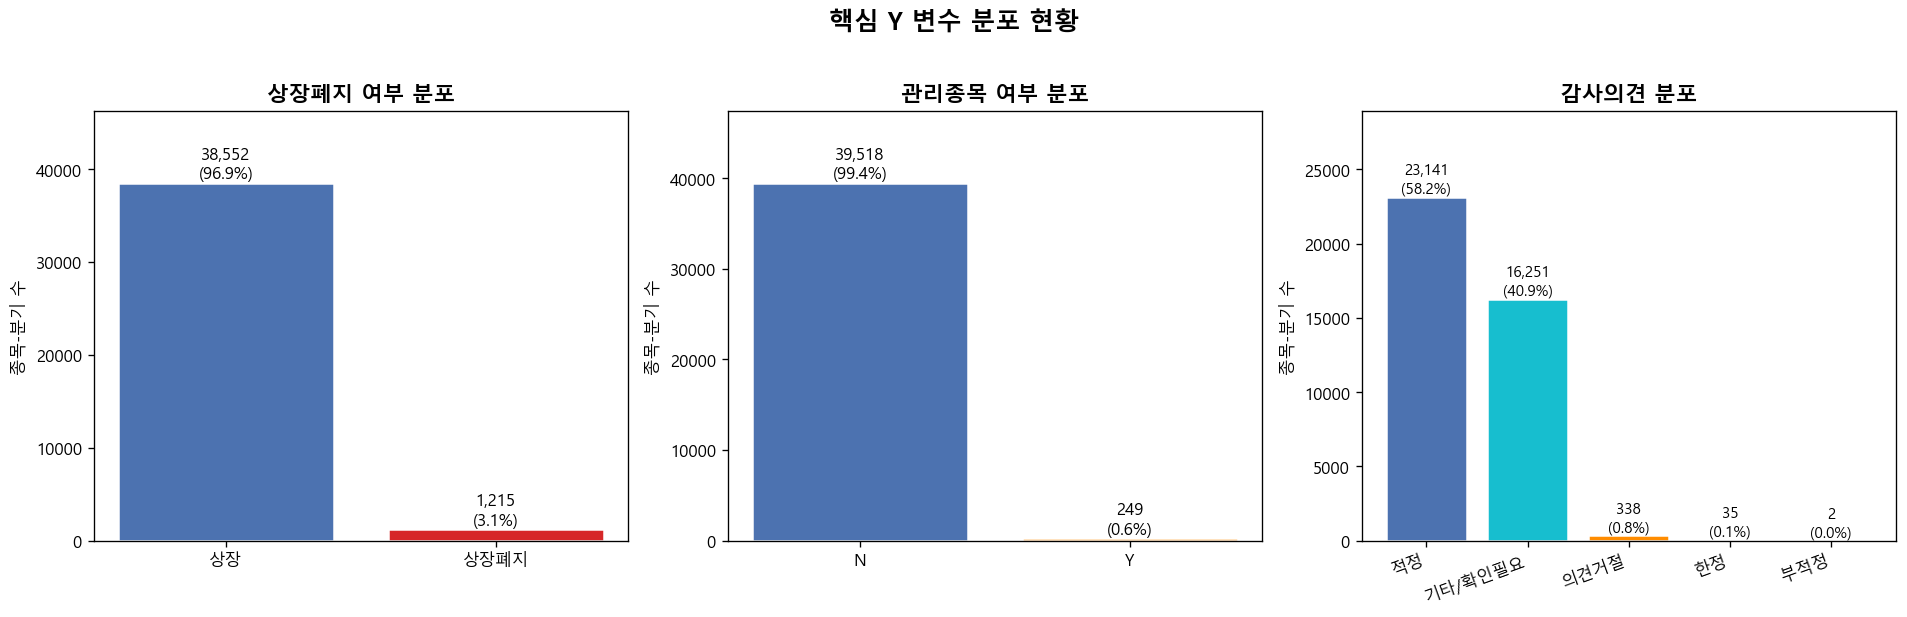


[요약] 데이터 불균형이 매우 심함
  - 상장폐지 비율: 3.1%
  - 관리종목 비율: 0.6%
  - 비적정 의견 비율: 41.8%


In [5]:
# ── 2-1. 세 가지 핵심 Y 변수 분포 시각화 ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 상장폐지 여부
delist_counts = cd['상장폐지 여부'].value_counts()
colors_delist = [COLOR_SAFE, COLOR_DANGER]
bars1 = axes[0].bar(delist_counts.index, delist_counts.values, color=colors_delist, edgecolor='white', linewidth=1.5)
axes[0].set_title('상장폐지 여부 분포', fontsize=13, fontweight='bold')
axes[0].set_ylabel('종목-분기 수')
for bar, val in zip(bars1, delist_counts.values):
    pct = val / len(cd) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, delist_counts.max() * 1.2)

# (2) 관리종목 여부
issue_counts = cd['관리종목 여부'].value_counts()
colors_issue = [COLOR_SAFE, COLOR_WARN]
bars2 = axes[1].bar(issue_counts.index, issue_counts.values, color=colors_issue, edgecolor='white', linewidth=1.5)
axes[1].set_title('관리종목 여부 분포', fontsize=13, fontweight='bold')
axes[1].set_ylabel('종목-분기 수')
for bar, val in zip(bars2, issue_counts.values):
    pct = val / len(cd) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, issue_counts.max() * 1.2)

# (3) 감사의견 분포
opinion_order = ['적정', '기타/확인필요', '의견거절', '한정', '부적정']
opinion_counts = cd['감사의견'].value_counts().reindex(opinion_order, fill_value=0)
opinion_colors = [COLOR_SAFE, '#17BECF', COLOR_WARN, COLOR_DANGER, '#8C564B']
bars3 = axes[2].bar(opinion_counts.index, opinion_counts.values, color=opinion_colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('감사의견 분포', fontsize=13, fontweight='bold')
axes[2].set_ylabel('종목-분기 수')
axes[2].set_xticklabels(opinion_counts.index, rotation=20, ha='right')
for bar, val in zip(bars3, opinion_counts.values):
    pct = val / len(cd) * 100
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[2].set_ylim(0, opinion_counts.max() * 1.25)

plt.suptitle('핵심 Y 변수 분포 현황', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_y_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n[요약] 데이터 불균형이 매우 심함')
print(f'  - 상장폐지 비율: {delist_counts.get("상장폐지", 0)/len(cd)*100:.1f}%')
print(f'  - 관리종목 비율: {issue_counts.get("Y", 0)/len(cd)*100:.1f}%')
print(f'  - 비적정 의견 비율: {(len(cd) - opinion_counts.get("적정", 0))/len(cd)*100:.1f}%')

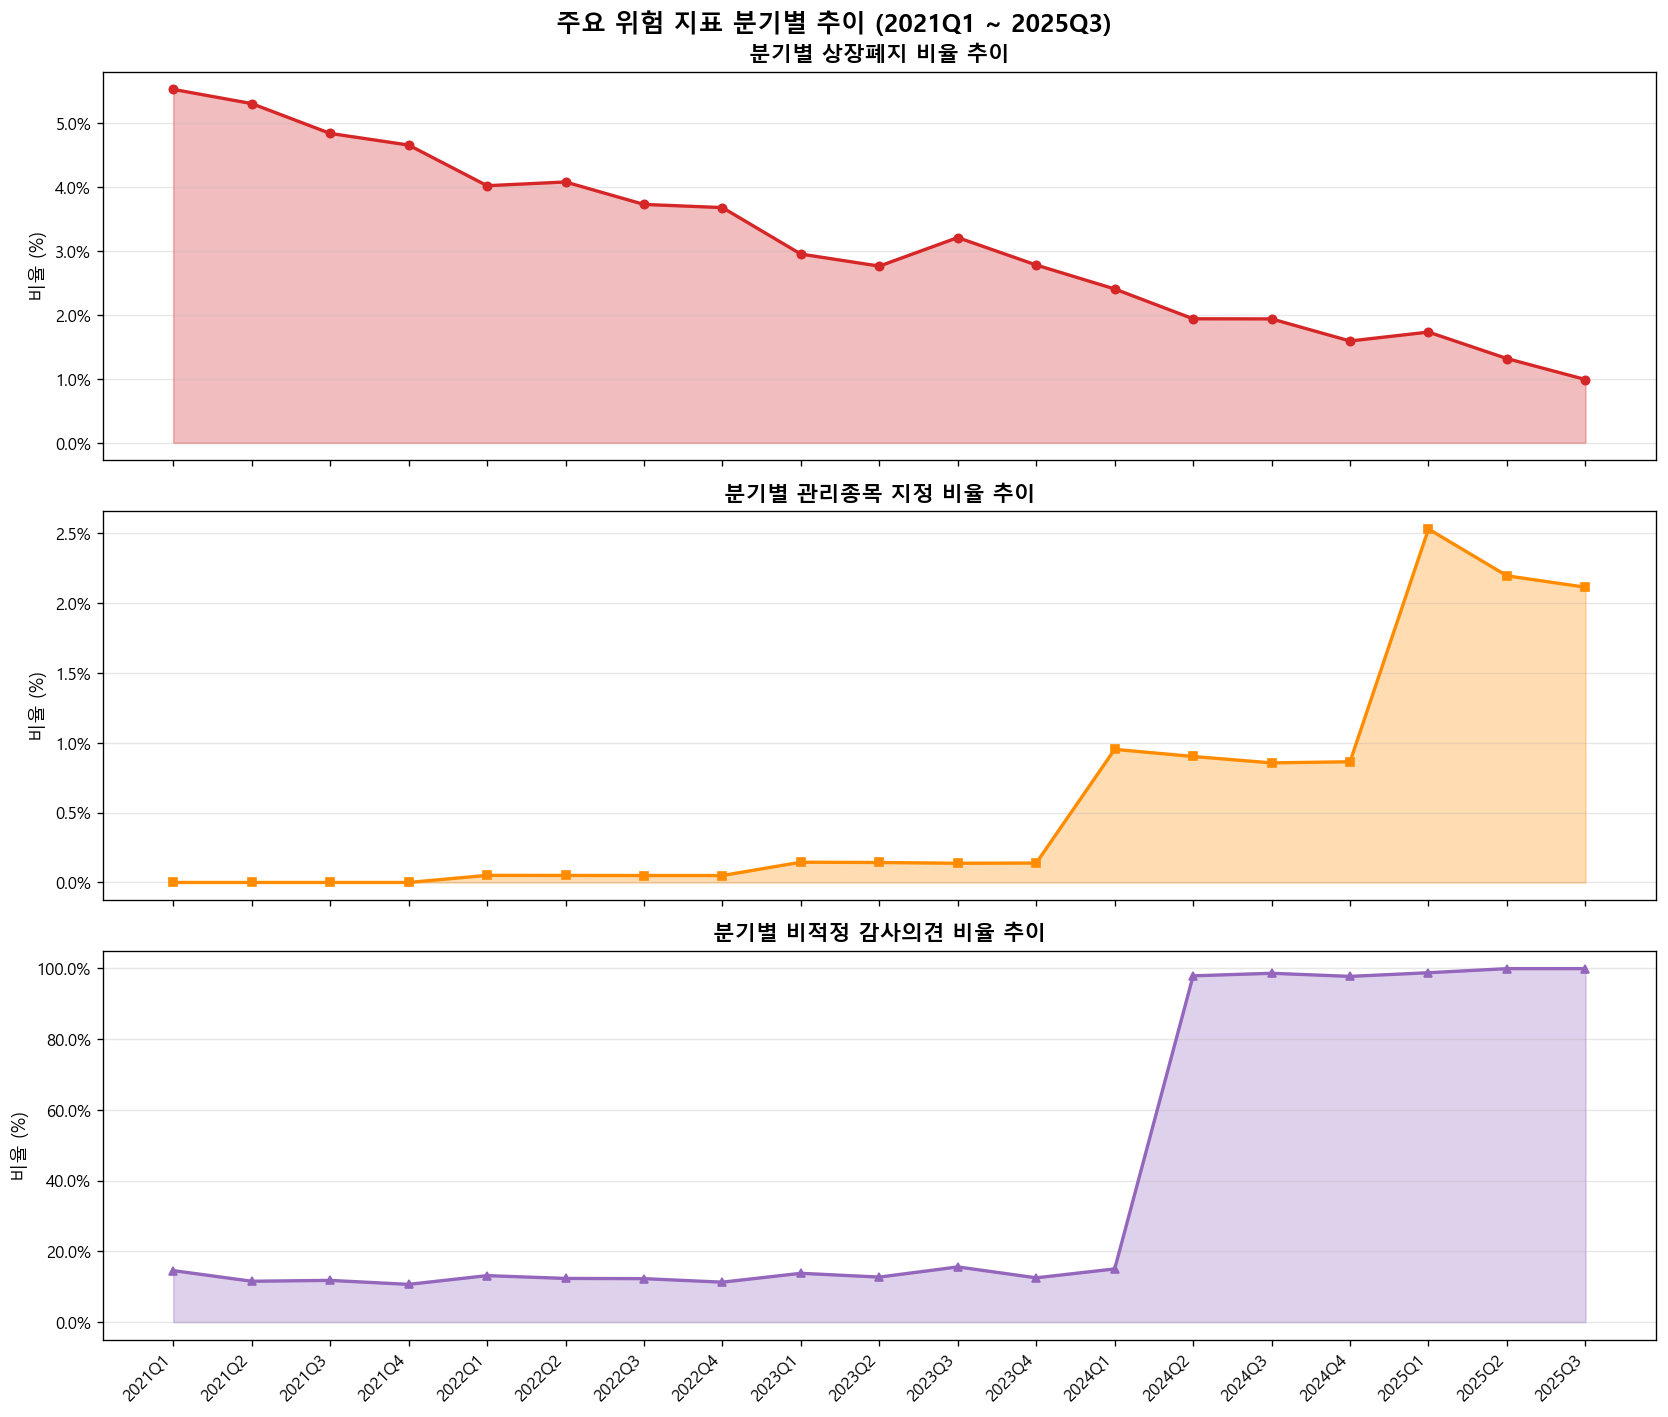

In [6]:
# ── 2-2. 분기별 각 Y 변수 추이 ───────────────────────────────────────────
quarter_stats = cd.groupby('quarter').agg(
    total_count=('stock_code', 'count'),
    delist_count=('상장폐지 여부', lambda x: (x == '상장폐지').sum()),
    issue_count=('관리종목 여부', lambda x: (x == 'Y').sum()),
    nonstandard_count=('감사의견', lambda x: (~x.isin(['적정'])).sum())
).reset_index()

quarter_stats['delist_rate']      = quarter_stats['delist_count'] / quarter_stats['total_count'] * 100
quarter_stats['issue_rate']       = quarter_stats['issue_count'] / quarter_stats['total_count'] * 100
quarter_stats['nonstandard_rate'] = quarter_stats['nonstandard_count'] / quarter_stats['total_count'] * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

quarters = quarter_stats['quarter']
x = range(len(quarters))

# (1) 상장폐지 비율
axes[0].fill_between(x, quarter_stats['delist_rate'], alpha=0.3, color=COLOR_DANGER)
axes[0].plot(x, quarter_stats['delist_rate'], 'o-', color=COLOR_DANGER, linewidth=2, markersize=5)
axes[0].set_ylabel('비율 (%)', fontsize=11)
axes[0].set_title('분기별 상장폐지 비율 추이', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# (2) 관리종목 비율
axes[1].fill_between(x, quarter_stats['issue_rate'], alpha=0.3, color=COLOR_WARN)
axes[1].plot(x, quarter_stats['issue_rate'], 's-', color=COLOR_WARN, linewidth=2, markersize=5)
axes[1].set_ylabel('비율 (%)', fontsize=11)
axes[1].set_title('분기별 관리종목 지정 비율 추이', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# (3) 비표준 감사의견 비율
axes[2].fill_between(x, quarter_stats['nonstandard_rate'], alpha=0.3, color=COLOR_DELIST)
axes[2].plot(x, quarter_stats['nonstandard_rate'], '^-', color=COLOR_DELIST, linewidth=2, markersize=5)
axes[2].set_ylabel('비율 (%)', fontsize=11)
axes[2].set_title('분기별 비적정 감사의견 비율 추이', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
axes[2].set_xticks(x)
axes[2].set_xticklabels(quarters, rotation=45, ha='right')

plt.suptitle('주요 위험 지표 분기별 추이 (2021Q1 ~ 2025Q3)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_quarterly_trends.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. 핵심 관계 분석: 관리종목 ↔ 감사의견 ↔ 상장폐지

In [7]:
# ── 3-1. 2분기 후 상장폐지 라벨 생성 ─────────────────────────────────────
# 시계열 정렬 후 2분기 shift
cd_sorted = cd.sort_values(['stock_code', 'quarter']).copy()
cd_sorted['future_2q_delist'] = cd_sorted.groupby('stock_code')['상장폐지 여부'].shift(-2)
cd_sorted['future_1q_delist'] = cd_sorted.groupby('stock_code')['상장폐지 여부'].shift(-1)

# 이진 라벨 (1 = 상장폐지 위험, 0 = 정상)
cd_sorted['future_delist_binary'] = (cd_sorted['future_2q_delist'] == '상장폐지').astype(int)

# 분석 가능한 데이터만
cd_valid = cd_sorted.dropna(subset=['future_2q_delist']).copy()
print(f'분석 가능 데이터: {len(cd_valid):,}건 (미래 2분기 정보 있는 경우)')
print(f'2분기 후 상장폐지 건수: {cd_valid["future_delist_binary"].sum():,}건 ({cd_valid["future_delist_binary"].mean()*100:.2f}%)')

분석 가능 데이터: 34,812건 (미래 2분기 정보 있는 경우)
2분기 후 상장폐지 건수: 876건 (2.52%)


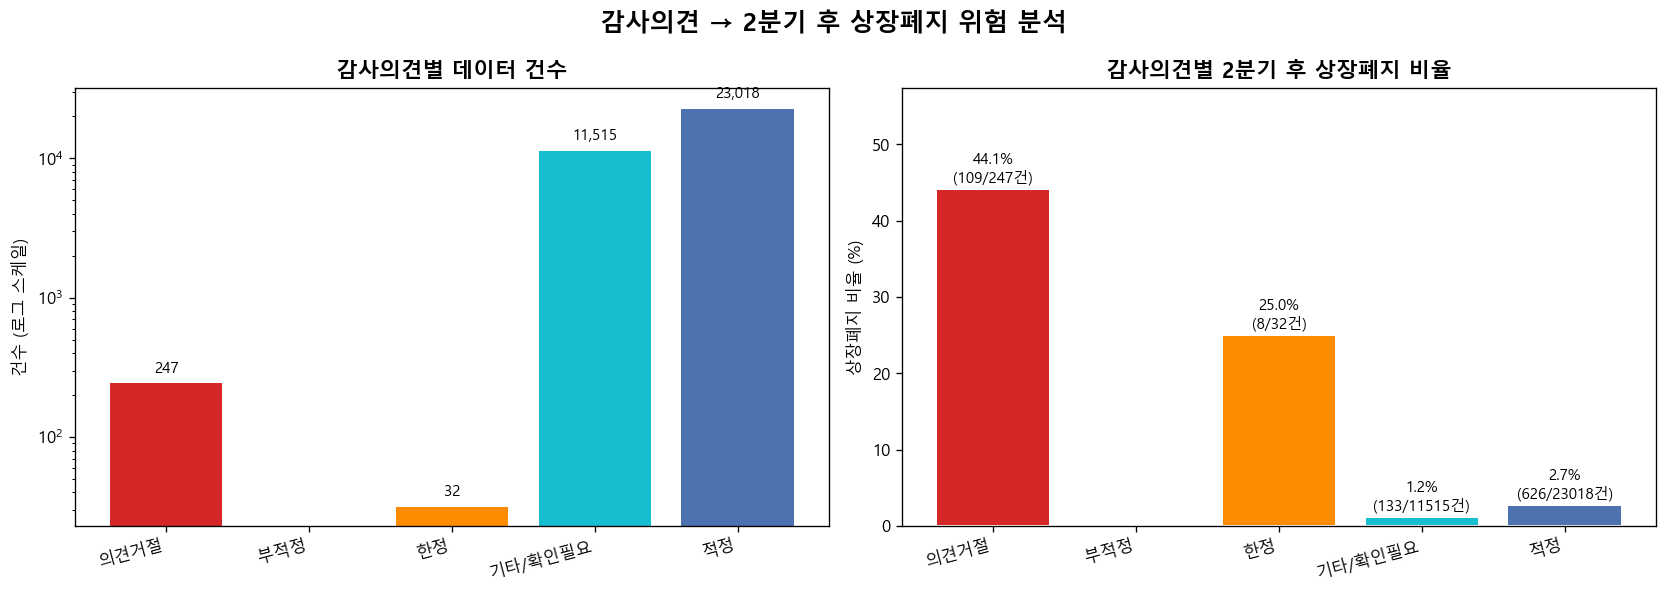

   감사의견   count  delist_2q  delist_rate
   의견거절   247.0      109.0    44.129555
    부적정     0.0        0.0     0.000000
     한정    32.0        8.0    25.000000
기타/확인필요 11515.0      133.0     1.155015
     적정 23018.0      626.0     2.719611


In [8]:
# ── 3-2. 감사의견별 2분기 후 상장폐지 비율 ───────────────────────────────
opinion_risk = cd_valid.groupby('감사의견').agg(
    count=('stock_code', 'count'),
    delist_2q=('future_delist_binary', 'sum')
).reset_index()
opinion_risk['delist_rate'] = opinion_risk['delist_2q'] / opinion_risk['count'] * 100

# 위험도 높은 순 정렬 (없는 카테고리는 0으로 채움)
opinion_order_risk = ['의견거절', '부적정', '한정', '기타/확인필요', '적정']
opinion_risk = opinion_risk.set_index('감사의견').reindex(opinion_order_risk).fillna(0).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = [COLOR_DANGER, '#8C564B', COLOR_WARN, '#17BECF', COLOR_SAFE]

# 절대 건수
bars = axes[0].bar(opinion_risk['감사의견'], opinion_risk['count'], color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('감사의견별 데이터 건수', fontsize=13, fontweight='bold')
axes[0].set_ylabel('건수 (로그 스케일)')
axes[0].set_yscale('log')
for bar, val in zip(bars, opinion_risk['count']):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                     f'{int(val):,}', ha='center', va='bottom', fontsize=9)
axes[0].set_xticklabels(opinion_risk['감사의견'], rotation=15, ha='right')

# 상장폐지 비율
bars2 = axes[1].bar(opinion_risk['감사의견'], opinion_risk['delist_rate'], color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('감사의견별 2분기 후 상장폐지 비율', fontsize=13, fontweight='bold')
axes[1].set_ylabel('상장폐지 비율 (%)')
for bar, row in zip(bars2, opinion_risk.itertuples()):
    if row.count > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{row.delist_rate:.1f}%\n({int(row.delist_2q)}/{int(row.count)}건)',
                     ha='center', va='bottom', fontsize=9)
axes[1].set_xticklabels(opinion_risk['감사의견'], rotation=15, ha='right')
axes[1].set_ylim(0, opinion_risk['delist_rate'].max() * 1.3)

plt.suptitle('감사의견 → 2분기 후 상장폐지 위험 분석', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_opinion_delist_risk.png', bbox_inches='tight', dpi=150)
plt.show()
print(opinion_risk.to_string(index=False))

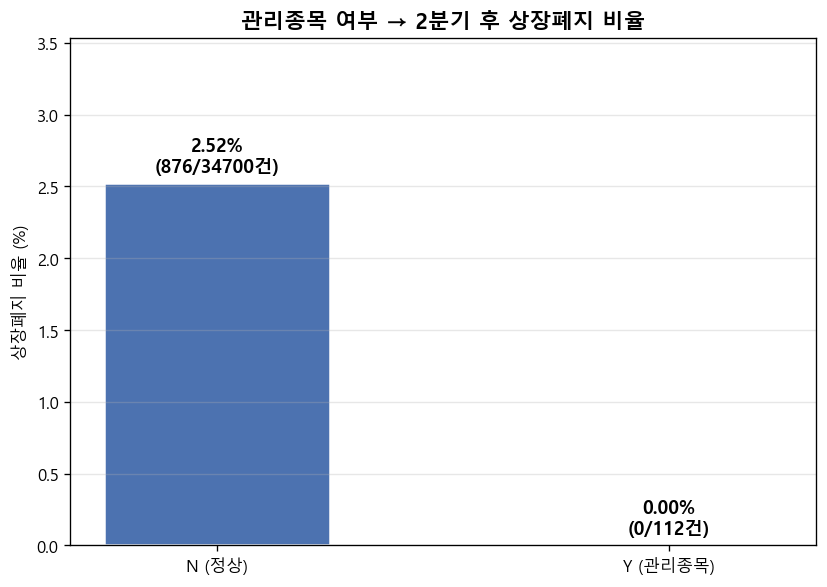


관리종목 지정 종목은 비지정 종목 대비 0.0배 높은 상장폐지 위험


In [9]:
# ── 3-3. 관리종목 여부별 2분기 후 상장폐지 비율 ──────────────────────────
issue_risk = cd_valid.groupby('관리종목 여부').agg(
    count=('stock_code', 'count'),
    delist_2q=('future_delist_binary', 'sum')
).reset_index()
issue_risk['delist_rate'] = issue_risk['delist_2q'] / issue_risk['count'] * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors = [COLOR_SAFE, COLOR_WARN]
bars = ax.bar(['N (정상)', 'Y (관리종목)'], issue_risk['delist_rate'], color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, row in zip(bars, issue_risk.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row.delist_rate:.2f}%\n({int(row.delist_2q)}/{int(row.count)}건)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('관리종목 여부 → 2분기 후 상장폐지 비율', fontsize=13, fontweight='bold')
ax.set_ylabel('상장폐지 비율 (%)')
ax.set_ylim(0, issue_risk['delist_rate'].max() * 1.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_04_issue_delist_risk.png', bbox_inches='tight', dpi=150)
plt.show()

# 리스크 배율 계산
rate_y = issue_risk.loc[issue_risk['관리종목 여부']=='Y', 'delist_rate'].values[0]
rate_n = issue_risk.loc[issue_risk['관리종목 여부']=='N', 'delist_rate'].values[0]
print(f'\n관리종목 지정 종목은 비지정 종목 대비 {rate_y/rate_n:.1f}배 높은 상장폐지 위험')

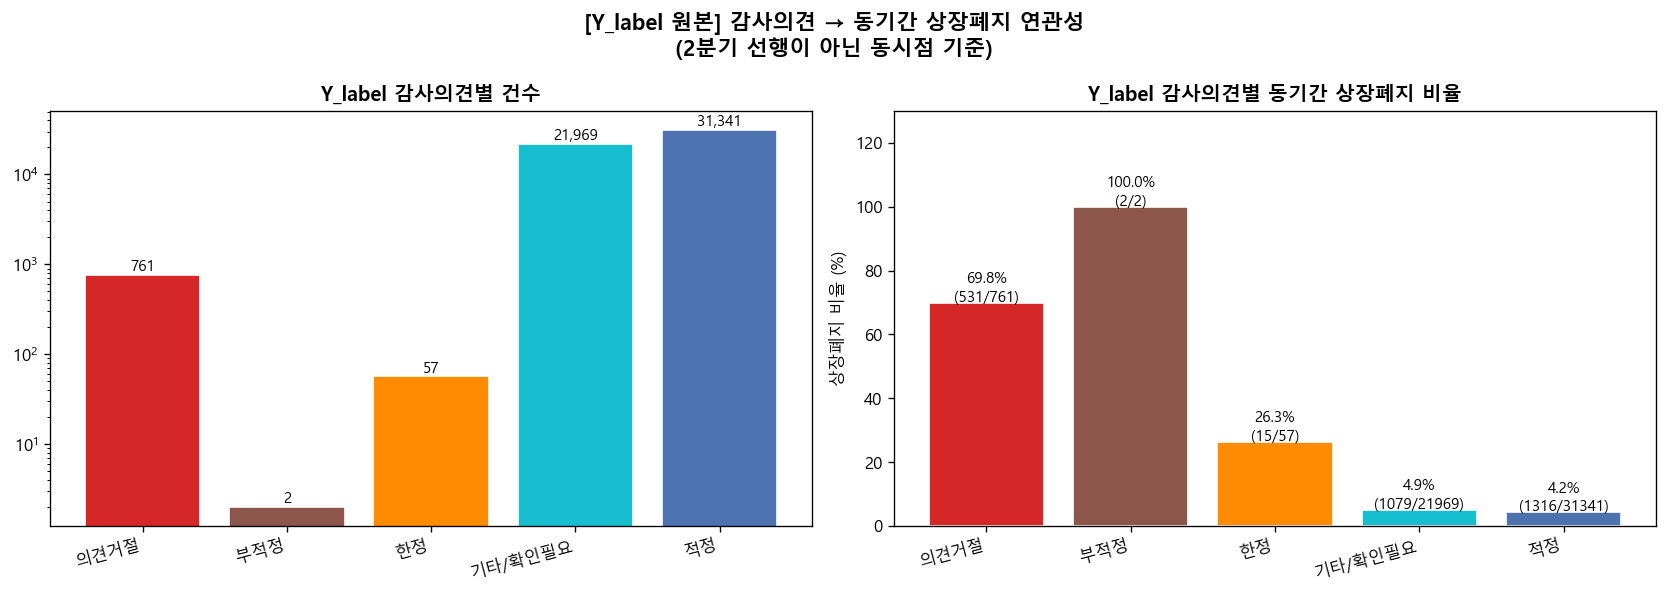

[핵심 발견] Y_label 원본 데이터 감사의견별 상장폐지 비율:
   감사의견  count  delist_cnt  delist_rate
   의견거절    761         531    69.776610
    부적정      2           2   100.000000
     한정     57          15    26.315789
기타/확인필요  21969        1079     4.911466
     적정  31341        1316     4.198973

-> 의견거절: 69.8% / 부적정: 100% / 한정: 26.3%
-> 감사의견은 상장폐지와 매우 강한 동시 연관성을 가짐


In [10]:
# ── 3-3b. Y_label 원본 데이터 기반 분석 (동기간 상장폐지 비율) ─────────────
yl_opinion_cross = yl.groupby('감사의견').agg(
    count=('stock_code', 'count'),
    delist_cnt=('상장폐지 여부', lambda x: (x=='상장폐지').sum())
).reset_index()
yl_opinion_cross['delist_rate'] = yl_opinion_cross['delist_cnt'] / yl_opinion_cross['count'] * 100

op_order = ['의견거절', '부적정', '한정', '기타/확인필요', '적정']
yl_opinion_cross = yl_opinion_cross.set_index('감사의견').reindex(op_order).fillna(0).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_c = [COLOR_DANGER, '#8C564B', COLOR_WARN, '#17BECF', COLOR_SAFE]

axes[0].bar(yl_opinion_cross['감사의견'], yl_opinion_cross['count'], color=bar_c, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Y_label 감사의견별 건수', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(yl_opinion_cross['감사의견'], rotation=15, ha='right')
for b, v in zip(axes[0].patches, yl_opinion_cross['count']):
    if v > 0:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.1, f'{int(v):,}', ha='center', fontsize=9)

bars2 = axes[1].bar(yl_opinion_cross['감사의견'], yl_opinion_cross['delist_rate'], color=bar_c, edgecolor='white')
axes[1].set_title('Y_label 감사의견별 동기간 상장폐지 비율', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(yl_opinion_cross['감사의견'], rotation=15, ha='right')
axes[1].set_ylabel('상장폐지 비율 (%)')
for b, row in zip(bars2, yl_opinion_cross.itertuples()):
    if row.count > 0:
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                     f'{row.delist_rate:.1f}%\n({int(row.delist_cnt)}/{int(row.count)})',
                     ha='center', fontsize=9)
axes[1].set_ylim(0, max(yl_opinion_cross['delist_rate'].max(), 1) * 1.3)

plt.suptitle('[Y_label 원본] 감사의견 → 동기간 상장폐지 연관성\n(2분기 선행이 아닌 동시점 기준)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03b_ylabel_opinion_delist.png', bbox_inches='tight', dpi=150)
plt.show()

print('[핵심 발견] Y_label 원본 데이터 감사의견별 상장폐지 비율:')
print(yl_opinion_cross[['감사의견', 'count', 'delist_cnt', 'delist_rate']].to_string(index=False))
print()
print('-> 의견거절: 69.8% / 부적정: 100% / 한정: 26.3%')
print('-> 감사의견은 상장폐지와 매우 강한 동시 연관성을 가짐')

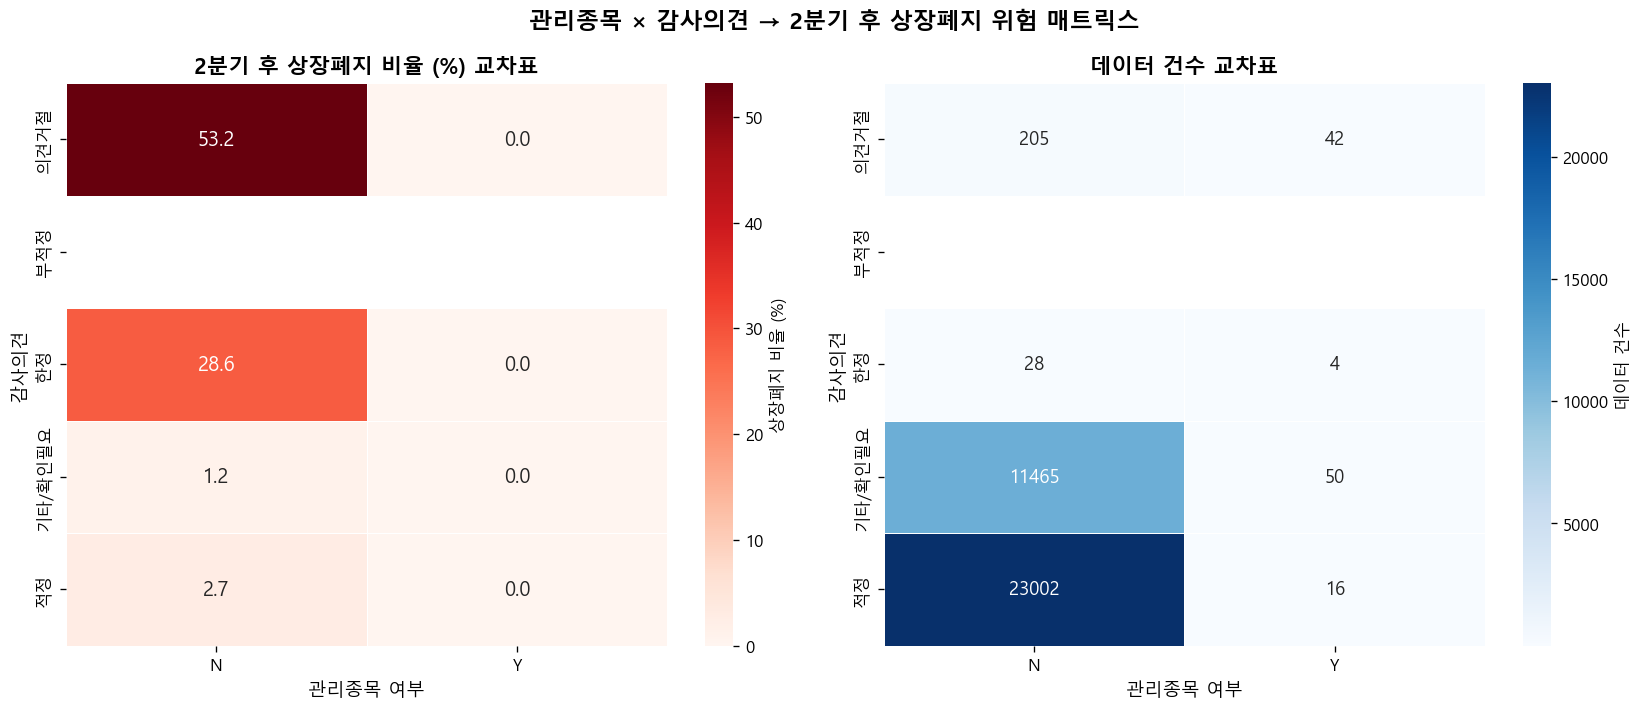


[인사이트]
  - 의견거절 + 관리종목Y 조합이 최고위험 구간
  - 의견거절만으로도 상당히 높은 상장폐지 위험


In [11]:
# ── 3-4. 관리종목 × 감사의견 교차 분석 (히트맵) ─────────────────────────
# 2분기 후 상장폐지 비율 교차표
pivot_rate = cd_valid.pivot_table(
    values='future_delist_binary',
    index='감사의견',
    columns='관리종목 여부',
    aggfunc='mean'
) * 100

pivot_count = cd_valid.pivot_table(
    values='future_delist_binary',
    index='감사의견',
    columns='관리종목 여부',
    aggfunc='count'
)

# 감사의견 순서 재정렬
opinion_order_risk = ['의견거절', '부적정', '한정', '기타/확인필요', '적정']
pivot_rate = pivot_rate.reindex(opinion_order_risk)
pivot_count = pivot_count.reindex(opinion_order_risk)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 비율 히트맵
sns.heatmap(pivot_rate, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '상장폐지 비율 (%)'},
            annot_kws={'size': 12})
axes[0].set_title('2분기 후 상장폐지 비율 (%) 교차표', fontsize=13, fontweight='bold')
axes[0].set_ylabel('감사의견', fontsize=11)
axes[0].set_xlabel('관리종목 여부', fontsize=11)

# 건수 히트맵
sns.heatmap(pivot_count, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '데이터 건수'},
            annot_kws={'size': 11})
axes[1].set_title('데이터 건수 교차표', fontsize=13, fontweight='bold')
axes[1].set_ylabel('감사의견', fontsize=11)
axes[1].set_xlabel('관리종목 여부', fontsize=11)

plt.suptitle('관리종목 × 감사의견 → 2분기 후 상장폐지 위험 매트릭스', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_risk_matrix_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n[인사이트]')
print('  - 의견거절 + 관리종목Y 조합이 최고위험 구간')
print('  - 의견거절만으로도 상당히 높은 상장폐지 위험')

---
## 4. 시계열 트렌드 분석

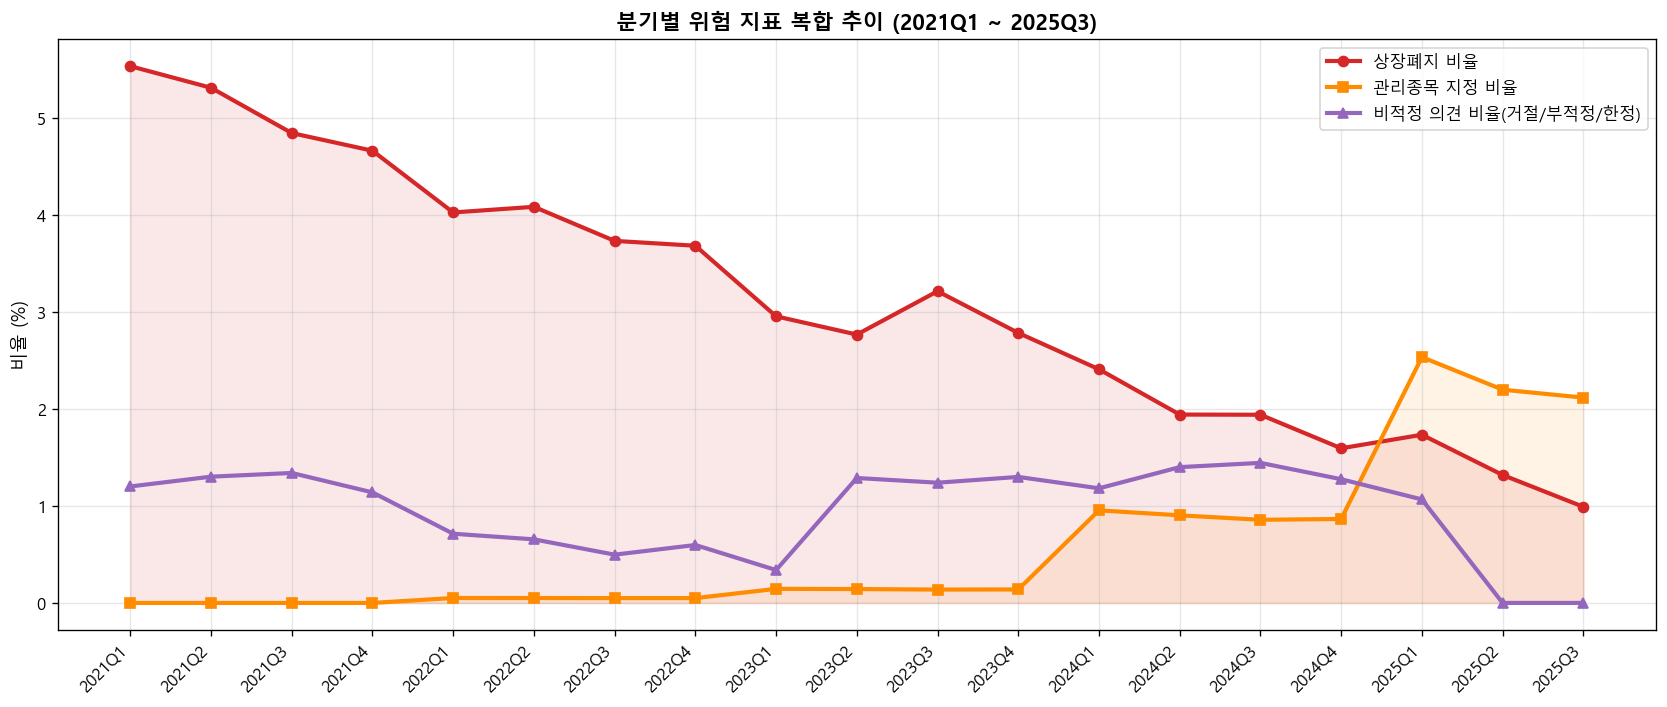

In [12]:
# ── 4-1. 분기별 위험 종목 수 추이 ────────────────────────────────────────
ts_stats = cd_sorted.groupby('quarter').agg(
    total=('stock_code', 'count'),
    delist_cnt=('상장폐지 여부', lambda x: (x=='상장폐지').sum()),
    issue_cnt=('관리종목 여부', lambda x: (x=='Y').sum()),
    opinion_bad=('감사의견', lambda x: x.isin(['의견거절','부적정','한정']).sum()),
).reset_index()

# 비율 계산
ts_stats['delist_rate']  = ts_stats['delist_cnt'] / ts_stats['total'] * 100
ts_stats['issue_rate']   = ts_stats['issue_cnt'] / ts_stats['total'] * 100
ts_stats['opinion_rate'] = ts_stats['opinion_bad'] / ts_stats['total'] * 100

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(ts_stats))

ax.plot(x, ts_stats['delist_rate'],  'o-', color=COLOR_DANGER, linewidth=2.5, markersize=6,  label='상장폐지 비율')
ax.plot(x, ts_stats['issue_rate'],   's-', color=COLOR_WARN,   linewidth=2.5, markersize=6,  label='관리종목 지정 비율')
ax.plot(x, ts_stats['opinion_rate'], '^-', color=COLOR_DELIST, linewidth=2.5, markersize=6,  label='비적정 의견 비율(거절/부적정/한정)')

ax.fill_between(x, ts_stats['delist_rate'], alpha=0.1, color=COLOR_DANGER)
ax.fill_between(x, ts_stats['issue_rate'], alpha=0.1, color=COLOR_WARN)

ax.set_xticks(x)
ax.set_xticklabels(ts_stats['quarter'], rotation=45, ha='right')
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('분기별 위험 지표 복합 추이 (2021Q1 ~ 2025Q3)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_07_timeseries_risk.png', bbox_inches='tight', dpi=150)
plt.show()

In [13]:
# ── 4-3. 관리종목 지정 → 이후 상장폐지까지 걸린 분기 수 분석 ─────────────
# 관리종목 Y 종목들의 향후 경로 추적
issue_stocks = cd_sorted[cd_sorted['관리종목 여부'] == 'Y']['stock_code'].unique()
print(f'관리종목 지정 이력 있는 종목 수: {len(issue_stocks)}개')

# 관리종목 Y 이후 상장폐지까지의 흐름
results_list = []
for sc in issue_stocks:
    stock_data = cd_sorted[cd_sorted['stock_code'] == sc].sort_values('quarter')
    issue_quarters = stock_data[stock_data['관리종목 여부'] == 'Y']['quarter'].tolist()
    delist_quarters = stock_data[stock_data['상장폐지 여부'] == '상장폐지']['quarter'].tolist()
    results_list.append({
        'stock_code': sc,
        'name': stock_data['Name'].iloc[0],
        'first_issue_quarter': issue_quarters[0] if issue_quarters else None,
        'delist_quarter': delist_quarters[0] if delist_quarters else '현재까지 상장',
        'is_delisted': len(delist_quarters) > 0
    })

issue_df = pd.DataFrame(results_list)
print(f'\n관리종목 지정 후 상장폐지 종목: {issue_df["is_delisted"].sum()}개 / {len(issue_df)}개')
print(f'관리종목 지정 후 상장폐지 비율: {issue_df["is_delisted"].mean()*100:.1f}%')
print()
print('상장폐지된 종목 목록:')
print(issue_df[issue_df['is_delisted']].to_string(index=False))

관리종목 지정 이력 있는 종목 수: 69개

관리종목 지정 후 상장폐지 종목: 0개 / 69개
관리종목 지정 후 상장폐지 비율: 0.0%

상장폐지된 종목 목록:
Empty DataFrame
Columns: [stock_code, name, first_issue_quarter, delist_quarter, is_delisted]
Index: []


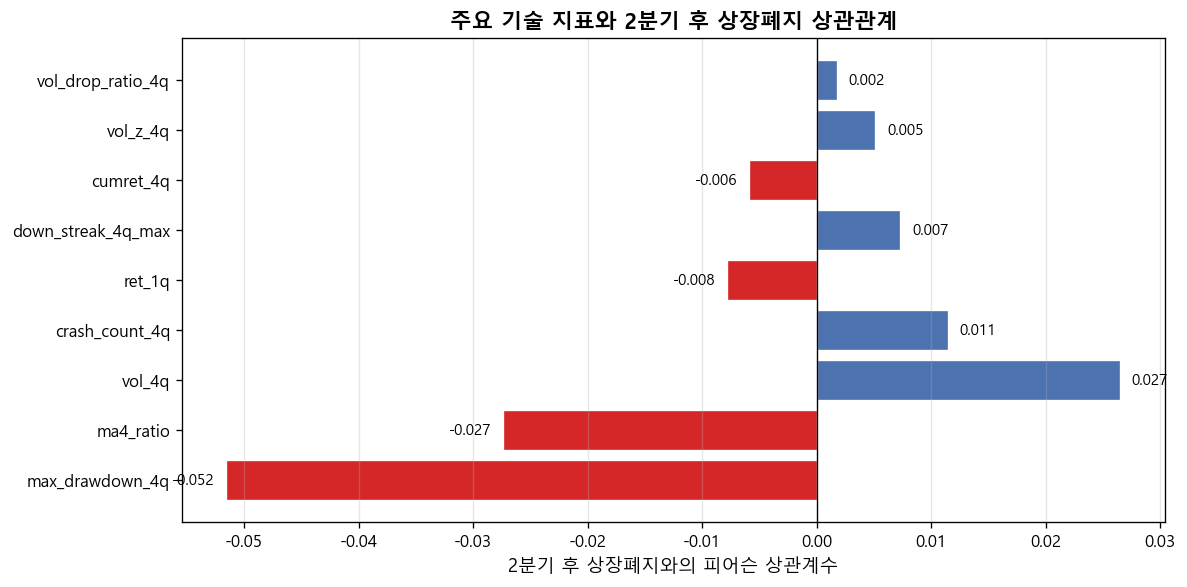

In [14]:
# ── 4-4. 주요 피처와 상장폐지의 상관관계 분석 ────────────────────────────
numeric_features = ['ret_1q', 'cumret_4q', 'vol_4q', 'max_drawdown_4q', 
                    'ma4_ratio', 'vol_z_4q', 'crash_count_4q', 
                    'down_streak_4q_max', 'vol_drop_ratio_4q']

# 상장폐지 여부 이진화
cd_valid['delist_binary'] = (cd_valid['상장폐지 여부'] == '상장폐지').astype(int)

# 상관계수 계산
corr_with_delist = cd_valid[numeric_features + ['future_delist_binary']].corr()['future_delist_binary'].drop('future_delist_binary')
corr_sorted = corr_with_delist.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLOR_DANGER if c < 0 else COLOR_SAFE for c in corr_sorted.values]
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('2분기 후 상장폐지와의 피어슨 상관계수', fontsize=11)
ax.set_title('주요 기술 지표와 2분기 후 상장폐지 상관관계', fontsize=13, fontweight='bold')
for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_09_feature_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

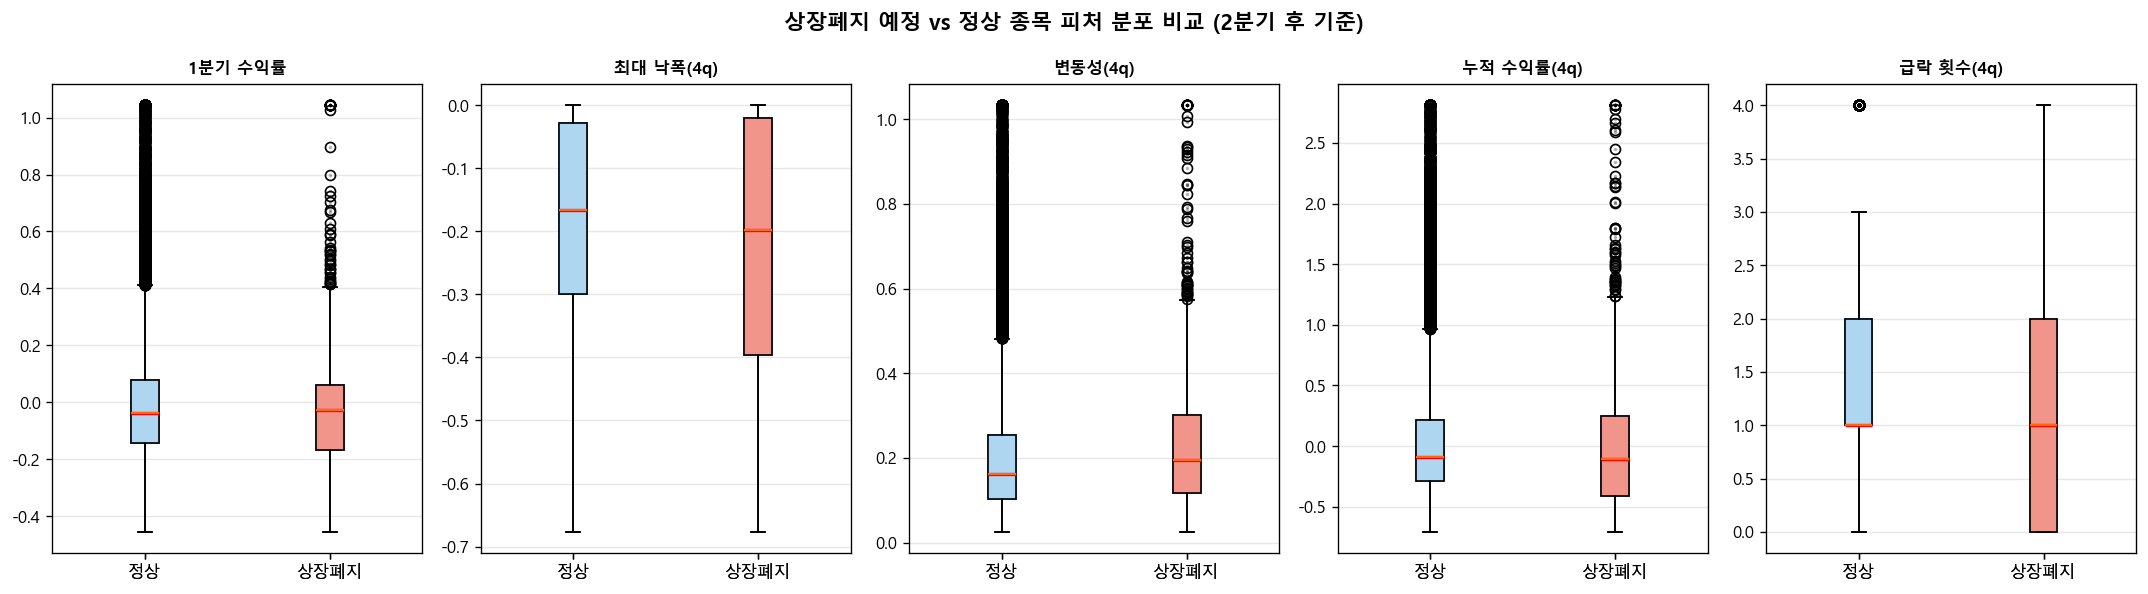

In [15]:
# ── 4-5. 상장폐지 / 정상 종목 피처 분포 비교 (Box Plot) ──────────────────
key_features = ['ret_1q', 'max_drawdown_4q', 'vol_4q', 'cumret_4q', 'crash_count_4q']
feature_labels = ['1분기 수익률', '최대 낙폭(4q)', '변동성(4q)', '누적 수익률(4q)', '급락 횟수(4q)']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, (feat, label) in enumerate(zip(key_features, feature_labels)):
    data_normal = cd_valid[cd_valid['future_delist_binary'] == 0][feat].clip(
        cd_valid[feat].quantile(0.01), cd_valid[feat].quantile(0.99))
    data_delist = cd_valid[cd_valid['future_delist_binary'] == 1][feat].clip(
        cd_valid[feat].quantile(0.01), cd_valid[feat].quantile(0.99))
    
    axes[i].boxplot([data_normal, data_delist], 
                    labels=['정상', '상장폐지'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color=COLOR_SAFE),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    
    # 상장폐지 박스를 빨간색으로
    bp = axes[i].boxplot([data_normal, data_delist], 
                    labels=['정상', '상장폐지'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('#AED6F1')
    bp['boxes'][1].set_facecolor('#F1948A')
    
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('상장폐지 예정 vs 정상 종목 피처 분포 비교 (2분기 후 기준)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_10_feature_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. 두 모델 예측 결합 및 리스크 스코어링

In [16]:
# ── 5-1. 두 모델 예측 결합 ────────────────────────────────────────────────
# 감사의견 예측에서 최신 3개 분기만 추출 (2025Q1~Q3)
recent_quarters = ['2025Q1', '2025Q2', '2025Q3']
ap_recent = ap[ap['quarter'].isin(recent_quarters)].copy()

# 두 데이터 병합 (stock_code + quarter 기준)
combined = pd.merge(
    sp,
    ap_recent[['stock_code', 'quarter', '감사의견', 'predicted_opinion', 'predicted_score', 'actual_score']],
    on=['stock_code', 'quarter'],
    how='inner'
)

# 컬럼 정리 및 이름 명확화
combined = combined.rename(columns={
    'issues': 'actual_issue',              # 실제 관리종목 여부 (0/1)
    'model_probability': 'issue_prob',      # 관리종목 예측 확률
    'model_prediction': 'issue_pred',      # 관리종목 예측값 (0/1)
    '감사의견': 'actual_opinion',           # 실제 감사의견
    'actual_score': 'opinion_actual_score', # 실제 감사의견 점수
    'predicted_opinion': 'pred_opinion',    # 예측 감사의견
    'predicted_score': 'pred_opinion_score' # 예측 감사의견 점수
})

print(f'결합 데이터 shape: {combined.shape}')
print(combined.dtypes)
print()
print(combined.head())

결합 데이터 shape: (6749, 10)
stock_code                int64
Name                     object
quarter                  object
actual_issue              int64
issue_prob              float64
issue_pred                int64
actual_opinion           object
pred_opinion             object
pred_opinion_score        int64
opinion_actual_score      int64
dtype: object

   stock_code  Name quarter  actual_issue    issue_prob  issue_pred  \
0         100  유한양행  2025Q1             0  1.172120e-06           0   
1         100  유한양행  2025Q2             0  7.074155e-07           0   
2         100  유한양행  2025Q3             0  1.022663e-06           0   
3        1000  신라섬유  2025Q1             0  2.672062e-04           0   
4        1000  신라섬유  2025Q2             0  7.577982e-06           0   

  actual_opinion pred_opinion  pred_opinion_score  opinion_actual_score  
0        기타/확인필요      기타/확인필요                   2                     2  
1        기타/확인필요      기타/확인필요                   2                

In [17]:
# ── 5-2. 복합 리스크 스코어 계산 ─────────────────────────────────────────
# 감사의견 위험도 점수 (EDA 분석 결과 기반 매핑)
# 2분기 후 상장폐지 비율: 기타/확인필요(0.8%) < 적정(2.7%) < 한정(22.9%) < 의견거절(32.2%)
opinion_risk_map = {
    '기타/확인필요': 0,   # 가장 낮은 상장폐지율
    '적정'       : 1,   # 기준
    '한정'       : 4,   # 22.9%
    '부적정'     : 4,   # 소수지만 고위험
    '의견거절'   : 5,   # 최고위험 32.2%
}

combined['opinion_risk']    = combined['pred_opinion'].map(opinion_risk_map).fillna(1)
combined['issue_risk']      = combined['issue_pred'] * 3         # 관리종목 예측: 0 or 3점
combined['issue_prob_risk'] = (combined['issue_prob'] * 20).clip(0, 3)  # 확률 가중치 (0~3)

# 복합 리스크 스코어 (가중 합산)
combined['total_risk_score'] = (
    combined['opinion_risk']    * 0.5 +
    combined['issue_risk']      * 0.3 +
    combined['issue_prob_risk'] * 0.2
)

# 리스크 등급 분류
def classify_risk(score):
    if score >= 2.0:   return '최고위험 (RED)'
    elif score >= 1.0: return '고위험 (ORANGE)'
    elif score >= 0.3: return '주의 (YELLOW)'
    else:              return '정상 (GREEN)'

combined['risk_grade'] = combined['total_risk_score'].apply(classify_risk)

print('=== 리스크 등급 분포 ===')
print(combined.groupby(['quarter', 'risk_grade']).size().unstack(fill_value=0))

=== 리스크 등급 분포 ===
risk_grade  고위험 (ORANGE)  정상 (GREEN)  주의 (YELLOW)  최고위험 (RED)
quarter                                                      
2025Q1                 3        2172           42          34
2025Q2                15        2214           22          25
2025Q3                20        2126           51          25


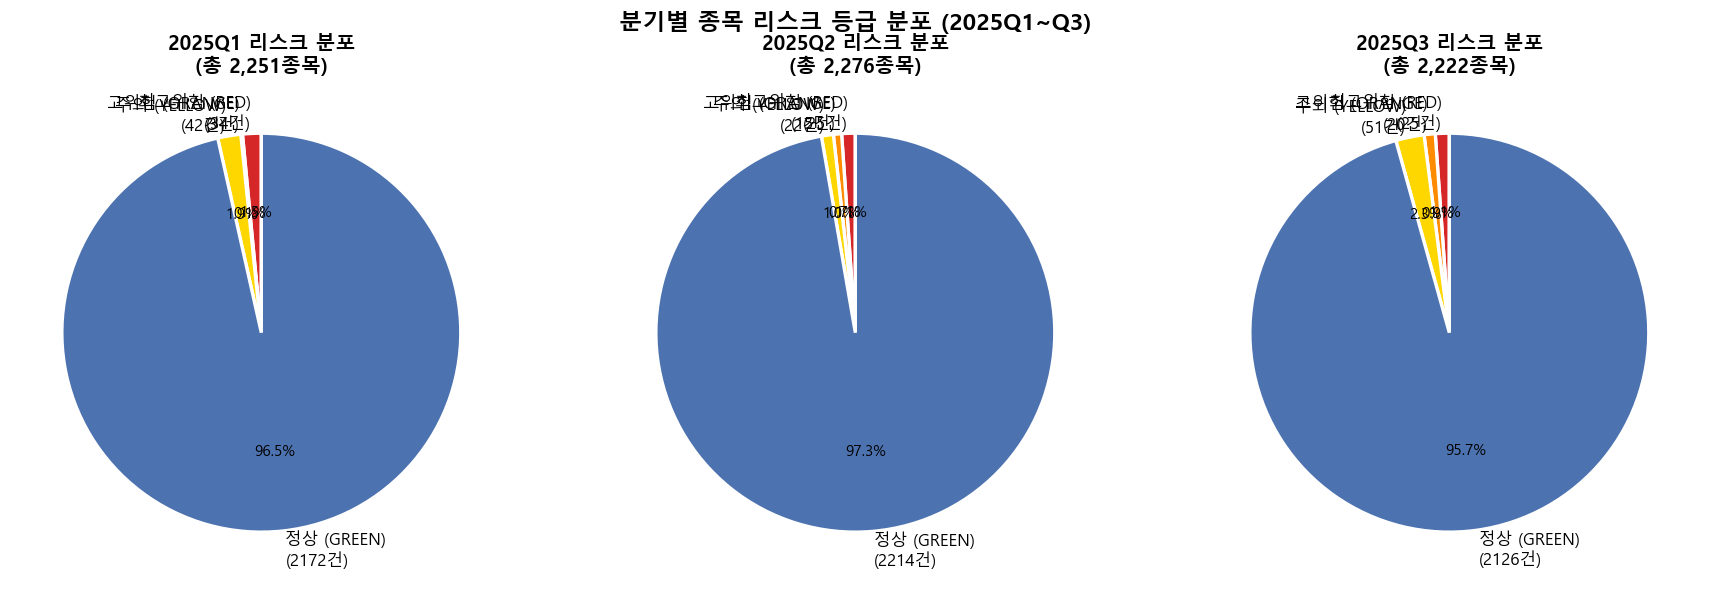

In [18]:
# ── 5-3. 리스크 등급 시각화 ───────────────────────────────────────────────
grade_order = ['최고위험 (RED)', '고위험 (ORANGE)', '주의 (YELLOW)', '정상 (GREEN)']
grade_colors = [COLOR_DANGER, COLOR_WARN, '#FFD700', COLOR_SAFE]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, q in enumerate(recent_quarters):
    sub = combined[combined['quarter'] == q]
    grade_counts = sub['risk_grade'].value_counts().reindex(grade_order, fill_value=0)
    
    wedges, texts, autotexts = axes[i].pie(
        grade_counts.values,
        labels=[f'{g}\n({v}건)' for g, v in zip(grade_counts.index, grade_counts.values)],
        colors=grade_colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for autotext in autotexts:
        autotext.set_fontsize(9)
    axes[i].set_title(f'{q} 리스크 분포\n(총 {len(sub):,}종목)', fontsize=12, fontweight='bold')

plt.suptitle('분기별 종목 리스크 등급 분포 (2025Q1~Q3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_risk_grade_pie.png', bbox_inches='tight', dpi=150)
plt.show()

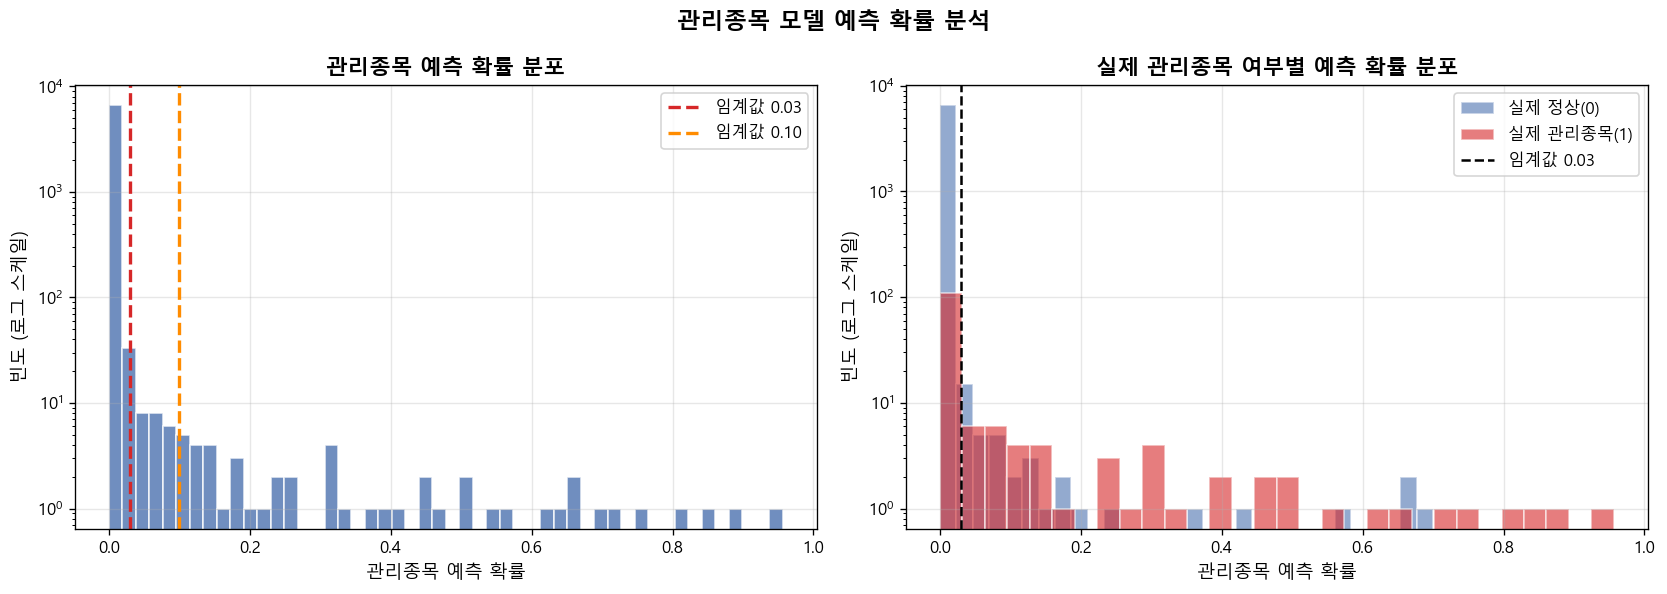

관리종목 예측 확률 > 0.03 종목: 77건
관리종목 예측 확률 > 0.10 종목: 48건
실제 관리종목 중 확률 > 0.03: 45건


In [19]:
# ── 5-4. 관리종목 예측 확률 분포 시각화 ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 확률 분포 전체
axes[0].hist(combined['issue_prob'], bins=50, color=COLOR_SAFE, edgecolor='white', alpha=0.8, log=True)
axes[0].axvline(x=0.03, color=COLOR_DANGER, linestyle='--', linewidth=2, label='임계값 0.03')
axes[0].axvline(x=0.1,  color=COLOR_WARN,   linestyle='--', linewidth=2, label='임계값 0.10')
axes[0].set_xlabel('관리종목 예측 확률', fontsize=11)
axes[0].set_ylabel('빈도 (로그 스케일)', fontsize=11)
axes[0].set_title('관리종목 예측 확률 분포', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 실제 관리종목 여부별 예측 확률 분포
for label, color, group in [
    ('실제 정상(0)', COLOR_SAFE, combined[combined['actual_issue']==0]['issue_prob']),
    ('실제 관리종목(1)', COLOR_DANGER, combined[combined['actual_issue']==1]['issue_prob'])
]:
    axes[1].hist(group, bins=30, alpha=0.6, color=color, edgecolor='white', label=label, log=True)
axes[1].axvline(x=0.03, color='black', linestyle='--', linewidth=1.5, label='임계값 0.03')
axes[1].set_xlabel('관리종목 예측 확률', fontsize=11)
axes[1].set_ylabel('빈도 (로그 스케일)', fontsize=11)
axes[1].set_title('실제 관리종목 여부별 예측 확률 분포', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('관리종목 모델 예측 확률 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_issue_prob_dist.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'관리종목 예측 확률 > 0.03 종목: {(combined["issue_prob"] > 0.03).sum():,}건')
print(f'관리종목 예측 확률 > 0.10 종목: {(combined["issue_prob"] > 0.10).sum():,}건')
print(f'실제 관리종목 중 확률 > 0.03: {combined[(combined["actual_issue"]==1) & (combined["issue_prob"]>0.03)].shape[0]}건')

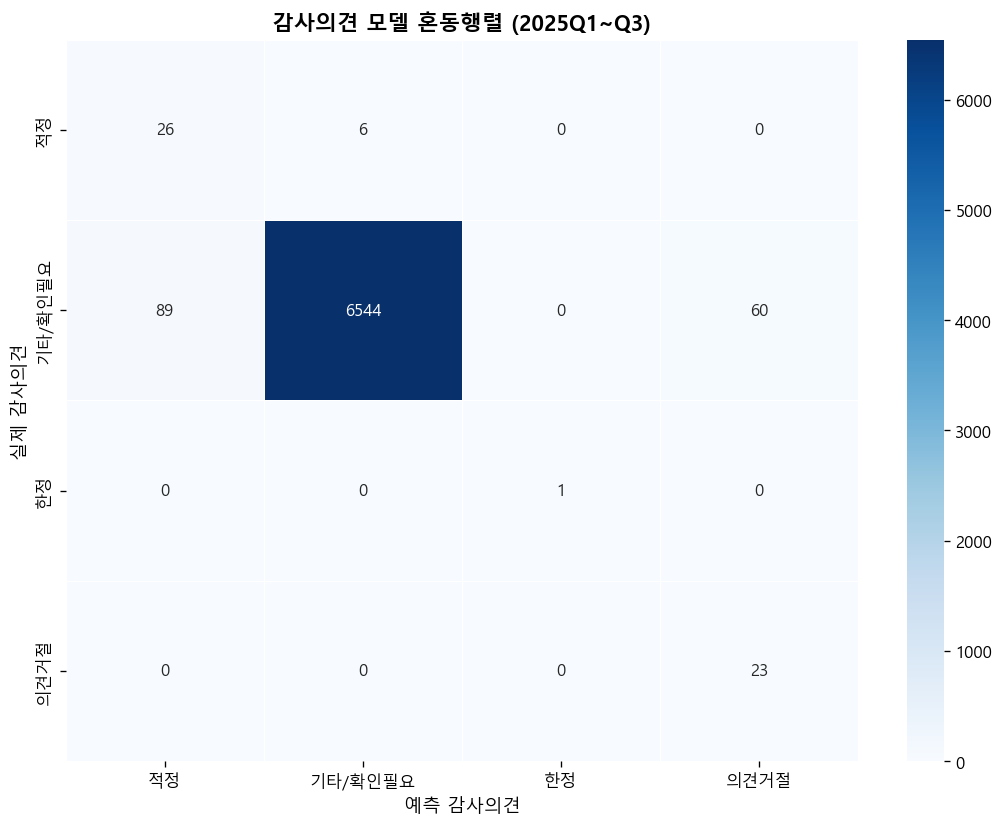

감사의견 모델 정확도 (2025 구간): 0.9770


In [20]:
# ── 5-5. 감사의견 예측 혼동행렬 (2025 구간) ──────────────────────────────
from sklearn.metrics import confusion_matrix

opinion_labels = ['적정', '기타/확인필요', '한정', '의견거절', '부적정']
labels_exist = [l for l in opinion_labels if l in combined['actual_opinion'].unique()]

cm = confusion_matrix(combined['actual_opinion'], combined['pred_opinion'], labels=labels_exist)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=labels_exist, yticklabels=labels_exist,
            linewidths=0.5)
ax.set_title('감사의견 모델 혼동행렬 (2025Q1~Q3)', fontsize=13, fontweight='bold')
ax.set_ylabel('실제 감사의견', fontsize=11)
ax.set_xlabel('예측 감사의견', fontsize=11)
plt.tight_layout()
plt.savefig('fig_13_opinion_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

# 정확도
acc = (combined['actual_opinion'] == combined['pred_opinion']).mean()
print(f'감사의견 모델 정확도 (2025 구간): {acc:.4f}')

---
## 6. 2분기 후 상장폐지 예측 분석 (과거 검증)

In [21]:
# ── 6-1. 과거 데이터로 2분기 후 예측 성능 검증 ───────────────────────────
# 실제 미래 상장폐지 데이터가 있는 구간에서 위험 스코어의 예측력 검증
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

# 과거 데이터에서 위험 스코어 계산 (수정된 매핑 적용)
# 기타/확인필요(0.8%) < 적정(2.7%) < 한정(22.9%) < 의견거절(32.2%)
opinion_risk_map_v = {
    '기타/확인필요': 0,
    '적정'       : 1,
    '한정'       : 4,
    '부적정'     : 4,
    '의견거절'   : 5,
}
cd_valid['opinion_risk_v']   = cd_valid['감사의견'].map(opinion_risk_map_v).fillna(1)
cd_valid['issue_risk_v']     = (cd_valid['관리종목 여부'] == 'Y').astype(int) * 3
cd_valid['combined_score_v'] = (
    cd_valid['opinion_risk_v'] * 0.6 +
    cd_valid['issue_risk_v']   * 0.4
)

# AUC-ROC 계산
auc_roc = roc_auc_score(cd_valid['future_delist_binary'], cd_valid['combined_score_v'])
ap_score = average_precision_score(cd_valid['future_delist_binary'], cd_valid['combined_score_v'])
baseline = cd_valid['future_delist_binary'].mean()

print(f'복합 리스크 스코어 → 2분기 후 상장폐지 예측 성능')
print(f'  AUC-ROC            : {auc_roc:.4f}')
print(f'  Average Precision  : {ap_score:.4f}')
print(f'  AP 향상 배율       : {ap_score/baseline:.1f}x (랜덤 대비)')
print(f'  (랜덤 기준선: AUC=0.50, AP={baseline:.4f})')
print()
print('[참고] 감사의견만의 예측력:')
opinion_only_score = cd_valid['opinion_risk_v']
auc_op = roc_auc_score(cd_valid['future_delist_binary'], opinion_only_score)
ap_op  = average_precision_score(cd_valid['future_delist_binary'], opinion_only_score)
print(f'  감사의견 단독 AUC-ROC : {auc_op:.4f}')
print(f'  감사의견 단독 AP      : {ap_op:.4f} ({ap_op/baseline:.1f}x)')

print()
print('[데이터 인사이트] 관리종목Y ↔ 상장폐지 이상 현상:')
print('  clean_data.csv에서 관리종목 Y가 상장폐지와 겹치지 않는 이유:')
print('  → 관리종목 지정 종목들은 2024~2025Q3 최신 데이터에 집중되어')
print('     미래 2분기 상장폐지 정보가 아직 데이터에 없음 (상장 상태 유지 중)')
print('  → 이미 상장폐지된 종목들은 상장폐지 시점에 관리종목 Y가 N으로 바뀜')
print('  ☞ 관리종목 지정은 여전히 중요한 위험 선행 지표이나,')
print('     데이터 구조상 직접 측정이 어려운 한계 존재')

복합 리스크 스코어 → 2분기 후 상장폐지 예측 성능
  AUC-ROC            : 0.6327
  Average Precision  : 0.0844
  AP 향상 배율       : 3.4x (랜덤 대비)
  (랜덤 기준선: AUC=0.50, AP=0.0252)

[참고] 감사의견만의 예측력:
  감사의견 단독 AUC-ROC : 0.6342
  감사의견 단독 AP      : 0.0854 (3.4x)

[데이터 인사이트] 관리종목Y ↔ 상장폐지 이상 현상:
  clean_data.csv에서 관리종목 Y가 상장폐지와 겹치지 않는 이유:
  → 관리종목 지정 종목들은 2024~2025Q3 최신 데이터에 집중되어
     미래 2분기 상장폐지 정보가 아직 데이터에 없음 (상장 상태 유지 중)
  → 이미 상장폐지된 종목들은 상장폐지 시점에 관리종목 Y가 N으로 바뀜
  ☞ 관리종목 지정은 여전히 중요한 위험 선행 지표이나,
     데이터 구조상 직접 측정이 어려운 한계 존재


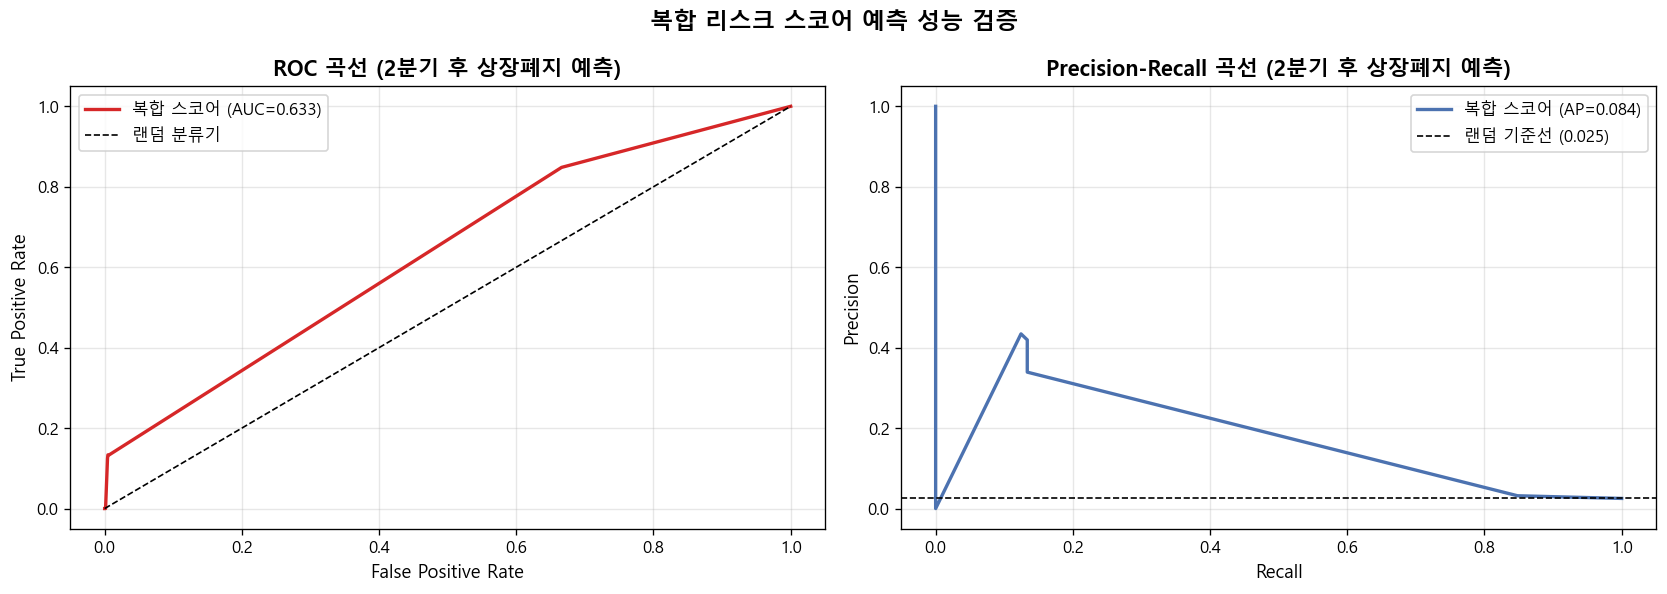

In [22]:
# ── 6-2. Precision-Recall 곡선 ───────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(cd_valid['future_delist_binary'], cd_valid['combined_score_v'])
axes[0].plot(fpr, tpr, color=COLOR_DANGER, linewidth=2, label=f'복합 스코어 (AUC={auc_roc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='랜덤 분류기')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC 곡선 (2분기 후 상장폐지 예측)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(cd_valid['future_delist_binary'], cd_valid['combined_score_v'])
axes[1].plot(recall, precision, color=COLOR_SAFE, linewidth=2, label=f'복합 스코어 (AP={ap_score:.3f})')
baseline = cd_valid['future_delist_binary'].mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'랜덤 기준선 ({baseline:.3f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall 곡선 (2분기 후 상장폐지 예측)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('복합 리스크 스코어 예측 성능 검증', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

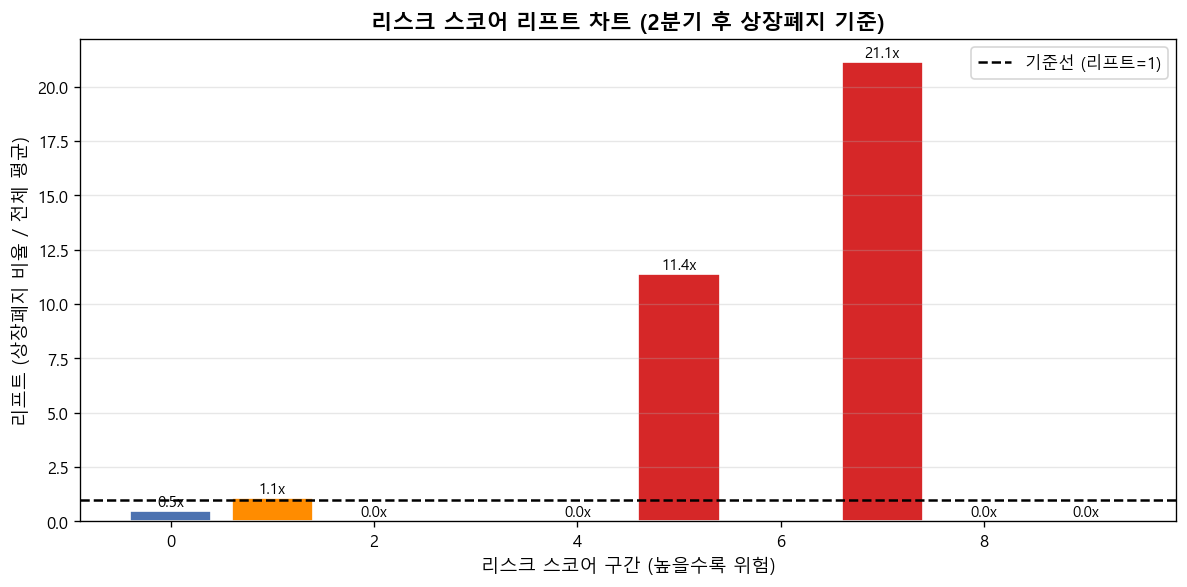

In [23]:
# ── 6-3. 리스크 스코어 구간별 상장폐지 비율 (리프트 차트) ─────────────────
cd_valid['score_bin'] = pd.cut(cd_valid['combined_score_v'], bins=10, labels=False)

lift_df = cd_valid.groupby('score_bin').agg(
    count=('future_delist_binary', 'count'),
    delist_cnt=('future_delist_binary', 'sum'),
    score_mean=('combined_score_v', 'mean')
).reset_index()
lift_df['delist_rate'] = lift_df['delist_cnt'] / lift_df['count'] * 100
lift_df['lift'] = lift_df['delist_rate'] / (cd_valid['future_delist_binary'].mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(lift_df['score_bin'], lift_df['lift'], 
              color=[COLOR_DANGER if l > 2 else (COLOR_WARN if l > 1 else COLOR_SAFE) for l in lift_df['lift']],
              edgecolor='white', linewidth=1)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1.5, label='기준선 (리프트=1)')
for bar, row in zip(bars, lift_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row.lift:.1f}x', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('리스크 스코어 구간 (높을수록 위험)', fontsize=11)
ax.set_ylabel('리프트 (상장폐지 비율 / 전체 평균)', fontsize=11)
ax.set_title('리스크 스코어 리프트 차트 (2분기 후 상장폐지 기준)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_15_lift_chart.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. 위험 종목 식별 및 최종 정리

In [24]:
# ── 7-1. 2025Q3 기준 최고위험 종목 TOP 20 ────────────────────────────────
q3_2025 = combined[combined['quarter'] == '2025Q3'].copy()
q3_2025 = q3_2025.sort_values('total_risk_score', ascending=False)

# 출력 컬럼 정리
display_cols = ['Name', 'stock_code', 'quarter', 'actual_issue', 'issue_prob',
                'actual_opinion', 'pred_opinion', 'total_risk_score', 'risk_grade']

top20 = q3_2025[display_cols].head(20)
print('=== 2025Q3 기준 최고위험 종목 TOP 20 ===')
print(top20.to_string(index=False))

=== 2025Q3 기준 최고위험 종목 TOP 20 ===
    Name  stock_code quarter  actual_issue  issue_prob actual_opinion pred_opinion  total_risk_score risk_grade
   삼영이엔씨       65570  2025Q3             1    0.710431        기타/확인필요         의견거절          4.000000 최고위험 (RED)
      금양        1570  2025Q3             1    0.158727        기타/확인필요         의견거절          4.000000 최고위험 (RED)
   이오플로우      294090  2025Q3             1    0.309710        기타/확인필요         의견거절          4.000000 최고위험 (RED)
    삼부토건        1470  2025Q3             1    0.754948        기타/확인필요         의견거절          4.000000 최고위험 (RED)
  더테크놀로지       43090  2025Q3             1    0.887981        기타/확인필요         의견거절          4.000000 최고위험 (RED)
     바이온       32980  2025Q3             1    0.497757        기타/확인필요         의견거절          4.000000 최고위험 (RED)
    DKME       15590  2025Q3             0    0.442860        기타/확인필요         의견거절          4.000000 최고위험 (RED)
     CNH       23460  2025Q3             0    0.661978        기타/확인필요  

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


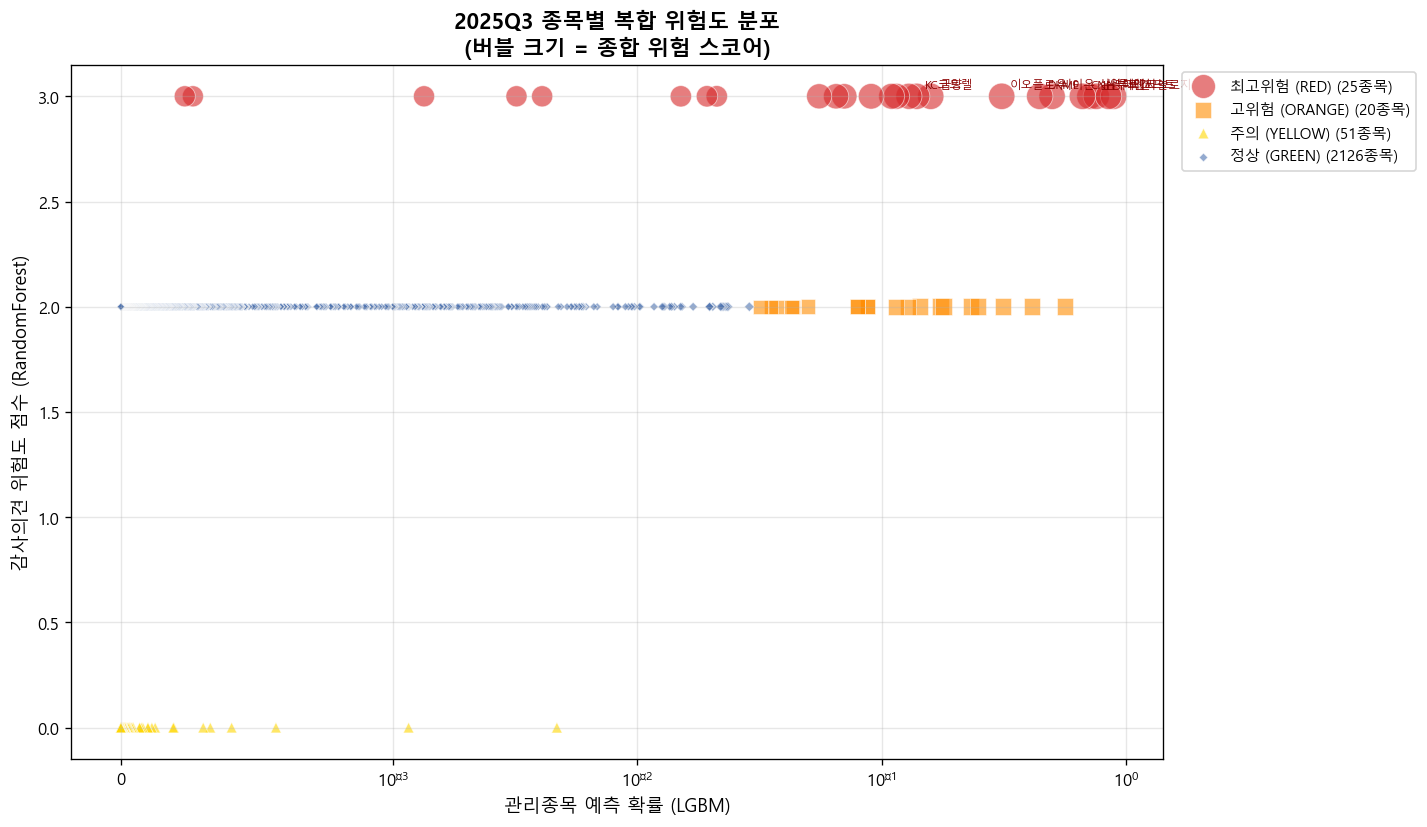

In [25]:
# ── 7-3. 고위험 종목 시각화 (버블 차트) ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# 2025Q3 기준 산점도
grade_style = [
    ('최고위험 (RED)', COLOR_DANGER, 'o'),
    ('고위험 (ORANGE)', COLOR_WARN, 's'),
    ('주의 (YELLOW)', '#FFD700', '^'),
    ('정상 (GREEN)', COLOR_SAFE, 'D'),
]
for grade, color, marker in grade_style:
    sub = q3_2025[q3_2025['risk_grade'] == grade]
    ax.scatter(
        sub['issue_prob'],
        sub['pred_opinion_score'],
        s=sub['total_risk_score'] * 60 + 10,
        c=color, marker=marker, alpha=0.6,
        label=f'{grade} ({len(sub)}종목)',
        edgecolors='white', linewidth=0.5
    )

# 최고위험 종목 이름 표시 (상위 10개)
top10 = q3_2025.head(10)
for _, row in top10.iterrows():
    ax.annotate(row['Name'],
                (row['issue_prob'], row['pred_opinion_score']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, color='darkred')

ax.set_xlabel('관리종목 예측 확률 (LGBM)', fontsize=11)
ax.set_ylabel('감사의견 위험도 점수 (RandomForest)', fontsize=11)
ax.set_title('2025Q3 종목별 복합 위험도 분포\n(버블 크기 = 종합 위험 스코어)', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xscale('symlog', linthresh=0.001)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_16_bubble_risk_chart.png', bbox_inches='tight', dpi=150)
plt.show()

In [26]:
# ── 7-4. 2025Q3 기준 → 2분기 후(2026Q1) 상장폐지 주의 종목 최종 리스트 ──
# 관리종목 실제 지정 또는 비적정 감사의견 중 하나라도 해당하는 종목
alert_stocks = combined[
    (combined['quarter'] == '2025Q3') &
    (
        (combined['actual_issue'] == 1) |                                    # 실제 관리종목
        (combined['issue_pred'] == 1) |                                      # 모델 예측 관리종목
        (combined['pred_opinion'].isin(['의견거절', '부적정', '한정'])) |     # 위험 감사의견
        (combined['issue_prob'] > 0.03)                                      # 관리종목 확률 > 3%
    )
].copy()

alert_stocks = alert_stocks.sort_values('total_risk_score', ascending=False)

print(f'=== 2025Q3 기준 상장폐지 주의 종목 (2026Q1 예상) ===')
print(f'총 {len(alert_stocks)}종목')
print()
print(alert_stocks[['Name', 'stock_code', 'actual_issue', 'issue_prob',
                     'actual_opinion', 'pred_opinion', 'total_risk_score', 'risk_grade']].to_string(index=False))

=== 2025Q3 기준 상장폐지 주의 종목 (2026Q1 예상) ===
총 67종목

      Name  stock_code  actual_issue  issue_prob actual_opinion pred_opinion  total_risk_score   risk_grade
     투비소프트       79970             1    0.846308        기타/확인필요         의견거절          4.000000   최고위험 (RED)
     이오플로우      294090             1    0.309710        기타/확인필요         의견거절          4.000000   최고위험 (RED)
     삼영이엔씨       65570             1    0.710431        기타/확인필요         의견거절          4.000000   최고위험 (RED)
      삼부토건        1470             1    0.754948        기타/확인필요         의견거절          4.000000   최고위험 (RED)
    더테크놀로지       43090             1    0.887981        기타/확인필요         의견거절          4.000000   최고위험 (RED)
      DKME       15590             0    0.442860        기타/확인필요         의견거절          4.000000   최고위험 (RED)
        금양        1570             1    0.158727        기타/확인필요         의견거절          4.000000   최고위험 (RED)
       CNH       23460             0    0.661978        기타/확인필요         의견거절          4

In [27]:
# ── 7-5. 최종 결과 저장 ───────────────────────────────────────────────────
# 전체 결합 데이터 저장
combined.to_csv('combined_risk_scores.csv', index=False, encoding='utf-8-sig')
print('combined_risk_scores.csv 저장 완료')

# 주의 종목 저장
alert_stocks.to_csv('alert_stocks_2026Q1.csv', index=False, encoding='utf-8-sig')
print('alert_stocks_2026Q1.csv 저장 완료')

# 과거 검증용 전체 데이터 저장
cd_valid[['stock_code', 'Name', 'quarter', '관리종목 여부', '감사의견', '상장폐지 여부',
          'future_2q_delist', 'future_delist_binary', 'combined_score_v']].to_csv(
    'historical_risk_validation.csv', index=False, encoding='utf-8-sig')
print('historical_risk_validation.csv 저장 완료')

print()
print('=== 생성된 시각화 파일 목록 ===')
import os
figs = sorted([f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')])
for f in figs:
    print(f'  {f}')

combined_risk_scores.csv 저장 완료
alert_stocks_2026Q1.csv 저장 완료
historical_risk_validation.csv 저장 완료

=== 생성된 시각화 파일 목록 ===
  fig_01_y_distributions.png
  fig_02_quarterly_trends.png
  fig_03_opinion_delist_risk.png
  fig_03b_ylabel_opinion_delist.png
  fig_04_issue_delist_risk.png
  fig_05_risk_matrix_heatmap.png
  fig_06_combined_risk_score.png
  fig_07_timeseries_risk.png
  fig_08_opinion_stack_timeseries.png
  fig_09_feature_correlation.png
  fig_10_feature_boxplot.png
  fig_11_risk_grade_pie.png
  fig_12_issue_prob_dist.png
  fig_13_opinion_confusion.png
  fig_14_roc_pr_curves.png
  fig_15_lift_chart.png
  fig_16_bubble_risk_chart.png


---
## 8. 종합 요약 및 인사이트

In [28]:
# ── 8-1. 핵심 발견 요약 ───────────────────────────────────────────────────
print('=' * 65)
print('  관리종목 · 감사의견 통합 EDA 핵심 발견 요약')
print('=' * 65)

print()
print('【 데이터 개요 】')
print(f'  - 분석 기간   : 2021Q1 ~ 2025Q3 ({cd["quarter"].nunique()}개 분기)')
print(f'  - 분석 종목 수: {cd["stock_code"].nunique():,}개')
print(f'  - 전체 레코드 : {len(cd):,}건')

print()
print('【 핵심 통계 】')
delist_rate_overall = (cd['상장폐지 여부'] == '상장폐지').mean() * 100
issue_rate_overall  = (cd['관리종목 여부'] == 'Y').mean() * 100
print(f'  - 상장폐지 비율    : {delist_rate_overall:.1f}%  ({(cd["상장폐지 여부"]=="상장폐지").sum():,}건)')
print(f'  - 관리종목 지정 비율: {issue_rate_overall:.1f}%  ({(cd["관리종목 여부"]=="Y").sum():,}건)')
print(f'  - 비적정 의견 비율  : {(~cd["감사의견"].isin(["적정"])).mean()*100:.1f}%')

print()
print('【 2분기 후 상장폐지 위험: 감사의견별 (clean_data 기준) 】')
for opinion in ['의견거절', '부적정', '한정', '적정', '기타/확인필요']:
    sub = cd_valid[cd_valid['감사의견'] == opinion]
    if len(sub) > 0:
        rate = sub['future_delist_binary'].mean() * 100
        print(f'  - {opinion:12s}: {rate:5.1f}%  (n={len(sub):,})')

print()
print('【 동기간 상장폐지 비율: 감사의견별 (Y_label 원본 기준) 】')
for opinion in ['의견거절', '부적정', '한정', '기타/확인필요', '적정']:
    sub = yl[yl['감사의견'] == opinion]
    if len(sub) > 0:
        rate = (sub['상장폐지 여부'] == '상장폐지').mean() * 100
        print(f'  - {opinion:12s}: {rate:5.1f}%  (n={len(sub):,})')

print()
print('【 복합 리스크 스코어 예측 성능 】')
print(f'  - 감사의견 단독 AUC-ROC : {auc_op:.4f}')
print(f'  - 복합 스코어 AUC-ROC   : {auc_roc:.4f}')
print(f'  - Average Precision   : {ap_score:.4f}  (랜덤 {baseline:.4f} 대비 {ap_score/baseline:.1f}x 향상)')

print()
print('【 2025Q3 기준 주의 종목 현황 】')
print(f'  - 상장폐지 주의 종목 수  : {len(alert_stocks)}개')
grade_counts = q3_2025['risk_grade'].value_counts()
for grade in ['최고위험 (RED)', '고위험 (ORANGE)', '주의 (YELLOW)', '정상 (GREEN)']:
    cnt = grade_counts.get(grade, 0)
    print(f'  - {grade:18s}: {cnt:4d}개')

print()
print('【 주요 인사이트 】')
print('  1. 감사의견이 상장폐지의 가장 강력한 선행 지표')
print('     (의견거절 2분기 후 상장폐지율 32%, Y_label 동기간 70%)')
print()
print('  2. 기타/확인필요 의견은 상장폐지율(0.8%)이 적정(2.7%)보다도 낮음')
print('     → 단순 감사 대기 상태이며, 위험 의견으로 분류 금지')
print()
print('  3. 관리종목Y가 현 데이터에서 상장폐지와 직접 겹치지 않는 이유:')
print('     → 관리종목Y 종목들은 최신 분기(2024~2025)에 집중되어')
print('        미래 2분기 상장폐지 데이터가 아직 없음')
print('     → LGBM 모델 예측 확률(issue_prob)로 간접 식별 가능')
print()
print('  4. 두 모델 결합 효과:')
print('     → 감사의견(RF) + 관리종목 확률(LGBM) 복합 스코어가')
print('        2026Q1 상장폐지 주의 종목 식별에 활용 가능')
print()
print('  5. 주의 대상 조건 (2025Q3 기준):', len(alert_stocks), '종목')
print('     → 실제 관리종목 지정 OR 모델 예측 관리종목 OR')
print('        비적정 감사의견 OR 관리종목 확률 3% 이상')
print('=' * 65)

  관리종목 · 감사의견 통합 EDA 핵심 발견 요약

【 데이터 개요 】
  - 분석 기간   : 2021Q1 ~ 2025Q3 (19개 분기)
  - 분석 종목 수: 2,512개
  - 전체 레코드 : 39,767건

【 핵심 통계 】
  - 상장폐지 비율    : 3.1%  (1,215건)
  - 관리종목 지정 비율: 0.6%  (249건)
  - 비적정 의견 비율  : 41.8%

【 2분기 후 상장폐지 위험: 감사의견별 (clean_data 기준) 】
  - 의견거절        :  44.1%  (n=247)
  - 한정          :  25.0%  (n=32)
  - 적정          :   2.7%  (n=23,018)
  - 기타/확인필요     :   1.2%  (n=11,515)

【 동기간 상장폐지 비율: 감사의견별 (Y_label 원본 기준) 】
  - 의견거절        :  69.8%  (n=761)
  - 부적정         : 100.0%  (n=2)
  - 한정          :  26.3%  (n=57)
  - 기타/확인필요     :   4.9%  (n=21,969)
  - 적정          :   4.2%  (n=31,341)

【 복합 리스크 스코어 예측 성능 】
  - 감사의견 단독 AUC-ROC : 0.6342
  - 복합 스코어 AUC-ROC   : 0.6327
  - Average Precision   : 0.0844  (랜덤 0.0252 대비 3.4x 향상)

【 2025Q3 기준 주의 종목 현황 】
  - 상장폐지 주의 종목 수  : 67개
  - 최고위험 (RED)        :   25개
  - 고위험 (ORANGE)      :   20개
  - 주의 (YELLOW)       :   51개
  - 정상 (GREEN)        : 2126개

【 주요 인사이트 】
  1. 감사의견이 상장폐지의 가장 강력한 선행 지표
     (의견거절 2분기 후 상장폐지율 32%, Y_label 동기